In [1]:
import os
import gc
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [2]:
import random

def seed_everything(seed: int = 69):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

seed_everything()

In [3]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [4]:
class Trainer:
    def __init__(self, model, criterion, optimizer, config):
        self.config = config

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

        self.model = model.to(config.device)
        self.criterion = criterion
        self.optimizer = optimizer

        self.setup_dataloader()

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self):
        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()

        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                axes[i, 0].imshow(img.permute(1, 2, 0).cpu())
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

            plt.show()

In [5]:
# рофло юнет

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(3, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(512, 1024)
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)
        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)
        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        return self.final(d1)

In [6]:
!uv pip install monai -q

In [7]:
# еще пачку приколов я возьму из монаи =)

from monai.networks.nets import UNet as MONAI_UNet
from monai.networks.nets import AttentionUnet
from monai.networks.nets import DynUNet

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-03-07 17:00:16.649237: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772902816.842524      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772902816.896155      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772902817.320825      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772902817.320878      24 computation_placer.cc:1

In [8]:
?AttentionUnet

In [9]:
?DynUNet

In [10]:
def build_model(name):
    if name == 'custom_unet':
        return UNet()
    if name == 'monai_unet':
        return MONAI_UNet(
            spatial_dims=2,
            in_channels=3,
            out_channels=1,
            channels=(32, 64, 128, 256, 512),
            strides=(2, 2, 2, 2)
        )
    if name == 'attention_unet':
        return AttentionUnet(
            spatial_dims=2,
            in_channels=3,
            out_channels=1,
            channels=(32, 64, 128, 256),
            strides=(2, 2, 2)
        )
    if name == 'dynunet':
        return DynUNet(
            spatial_dims=2,
            in_channels=3,
            out_channels=1,
            kernel_size=[3, 3, 3, 3],
            strides=[1, 2, 2, 2],
            upsample_kernel_size=[2, 2, 2]
        )

In [11]:
from monai.losses import (
    DiceLoss,
    DiceCELoss,
    DiceFocalLoss,
    GeneralizedDiceLoss,
    TverskyLoss
)

In [12]:
def build_loss(name):
    if name == 'dice':
        return DiceLoss(sigmoid=True)
    if name == 'dice_ce':
        return DiceCELoss(sigmoid=True)
    if name == 'dice_focal':
        return DiceFocalLoss(sigmoid=True)
    if name == 'tversky':
        return TverskyLoss(sigmoid=True)
    if name == 'generalized_dice':
        return GeneralizedDiceLoss(sigmoid=True)
    if name == 'dice_ce_combo':
        dice = DiceLoss(sigmoid=True)
        bce = nn.BCEWithLogitsLoss()
        def _loss(x, y):
            return dice(x, y) + bce(x, y)
        return _loss

In [13]:
def build_optimizer(name, model, lr):
    if name == 'adamw':
        return optim.AdamW(model.parameters(), lr=lr)
    if name == 'muon':
        return None # чето впадлу щас чучут

In [14]:
@dataclass
class Config:
    image_size = (128, 128)
    epochs = 20 # я зафиксирую чтоб еще эту хуйню не тюнить пусть стоит 20
    batch_size = 32 # это тоже фиксану пусть остальное тюнится под эти установки
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8
    
config = Config()

In [15]:
import optuna
import pandas as pd

In [16]:
# https://optuna.readthedocs.io/en/stable/tutorial/20_recipes/002_multi_objective.html
def objective(trial):
    model_name = trial.suggest_categorical(
        'model',
        ['custom_unet', 'monai_unet', 'attention_unet', 'dynunet']
    )
    loss_name = trial.suggest_categorical(
        'loss',
        ['dice', 'dice_ce', 'dice_focal', 'tversky', 'generalized_dice', 'dice_ce_combo']
    )
    optimizer_name = 'adamw'#trial.suggest_categorical(
    #     'optimizer',
    #     ['adamw', 'muon']
    # )
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)

    print(f'{model_name=}, {loss_name=}, {lr=}')

    model = build_model(model_name)
    criterion = build_loss(loss_name)
    optimizer = build_optimizer(
        optimizer_name,
        model,
        lr
    )
    trainer = Trainer(
        model,
        criterion,
        optimizer,
        config
    )

    trainer.run()

    val_loss, val_iou, val_f1 = trainer.validate()

    del model, criterion, optimizer, trainer
    torch.cuda.empty_cache()
    gc.collect()

    trial.set_user_attr('iou', val_iou)
    trial.set_user_attr('f1', val_f1)

    return val_iou, val_f1

In [17]:
study = optuna.create_study(directions=['maximize', 'maximize'])

[I 2026-03-07 17:00:30,006] A new study created in memory with name: no-name-710f8724-cbeb-4d37-a901-18ff4884a72e


In [18]:
study.optimize(objective, n_trials=100, timeout=3600 * 11)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


model_name='monai_unet', loss_name='dice_ce', lr=2.819266871203541e-05


100%|██████████| 792M/792M [00:23<00:00, 33.7MB/s]
100%|██████████| 19.2M/19.2M [00:00<00:00, 19.5MB/s]
100%|██████████| 23/23 [00:08<00:00,  2.66it/s]


Epoch 1 / 20, Train Loss: 1.0697, Val Loss: 0.9329, Val IoU: 0.6141, Val F1-score: 0.7565


100%|██████████| 23/23 [00:08<00:00,  2.67it/s]


...

100%|██████████| 23/23 [00:08<00:00,  2.82it/s]


Epoch 20 / 20, Train Loss: 0.1548, Val Loss: 0.6424, Val IoU: 0.8050, Val F1-score: 0.8872
Testing...


100%|██████████| 115/115 [00:41<00:00,  2.75it/s]


Test Loss: 0.6715, Test IoU: 0.7956, Test F1-score: 0.8797


100%|██████████| 23/23 [00:07<00:00,  2.94it/s]
[I 2026-03-08 04:08:03,973] Trial 55 finished with values: [0.8049553855004122, 0.8871693876722032] and parameters: {'model': 'monai_unet', 'loss': 'dice_ce_combo', 'lr': 0.00011968377647127447}.


In [19]:
df = study.trials_dataframe()
df.to_csv('optim_logs.csv', index=False)
df.sort_values('values_0', ascending=False).head()

,number,values_0,values_1,datetime_start,datetime_complete,duration,params_loss,params_lr,params_model,user_attrs_f1,user_attrs_iou,system_attrs_NSGAIISampler:generation,state
34,34,0.903513,0.946402,2026-03-07 23:39:29.688980,2026-03-07 23:54:52.106464,0 days 00:15:22.417484,dice_ce,0.000495,custom_unet,0.946402,0.903513,0,COMPLETE
3,3,0.902203,0.945874,2026-03-07 17:32:16.454989,2026-03-07 17:48:34.522090,0 days 00:16:18.067101,dice_ce_combo,0.000299,custom_unet,0.945874,0.902203,0,COMPLETE
26,26,0.898534,0.943337,2026-03-07 22:04:28.636933,2026-03-07 22:19:49.908848,0 days 00:15:21.271915,dice_focal,0.000181,custom_unet,0.943337,0.898534,0,COMPLETE
9,9,0.888820,0.937961,2026-03-07 18:38:24.392769,2026-03-07 18:54:06.313063,0 days 00:15:41.920294,dice,0.000963,custom_unet,0.937961,0.888820,0,COMPLETE
44,44,0.887656,0.937368,2026-03-08 01:42:02.775449,2026-03-08 01:57:58.001716,0 days 00:15:55.226267,tversky,0.000501,custom_unet,0.937368,0.887656,0,COMPLETE


In [20]:
import optuna.visualization as vis

In [21]:
optuna.visualization.plot_pareto_front(study, target_names=['iou', 'f1'])

In [22]:
vis.plot_optimization_history(study, target=lambda t: t.values[0], target_name='iou')

In [23]:
vis.plot_optimization_history(study, target=lambda t: t.values[1], target_name='f1')

In [24]:
vis.plot_param_importances(study, target=lambda t: t.values[0], target_name='iou')

In [25]:
vis.plot_param_importances(study, target=lambda t: t.values[1], target_name='f1')

In [26]:
vis.plot_parallel_coordinate(study, target=lambda t: t.values[0], target_name='iou')

In [27]:
vis.plot_parallel_coordinate(study, target=lambda t: t.values[1], target_name='f1')

In [28]:
best = study.best_trials[0].params

model = build_model(best['model'])
criterion = build_loss(best['loss'])

optimizer = build_optimizer(
    'adamw',#best['optimizer'],
    model,
    best['lr']
)

In [29]:
trainer = Trainer(
    model,
    criterion,
    optimizer,
    config
)

trainer.run()

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning:

The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.

100%|██████████| 23/23 [00:09<00:00,  2.52it/s]


Epoch 1 / 20, Train Loss: 0.6327, Val Loss: 0.5259, Val IoU: 0.7958, Val F1-score: 0.8803


100%|██████████| 23/23 [00:09<00:00,  2.53it/s]


Epoch 2 / 20, Train Loss: 0.4675, Val Loss: 0.4721, Val IoU: 0.8123, Val F1-score: 0.8915


100%|██████████| 23/23 [00:09<00:00,  2.44it/s]


...

Epoch 19 / 20, Train Loss: 0.1522, Val Loss: 0.2482, Val IoU: 0.9042, Val F1-score: 0.9468


100%|██████████| 23/23 [00:09<00:00,  2.54it/s]


Epoch 20 / 20, Train Loss: 0.1489, Val Loss: 0.2725, Val IoU: 0.8976, Val F1-score: 0.9425
Testing...


100%|██████████| 115/115 [00:46<00:00,  2.45it/s]

Test Loss: 0.2784, Test IoU: 0.8959, Test F1-score: 0.9410


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9843137..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..0.8352941].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.99215686].


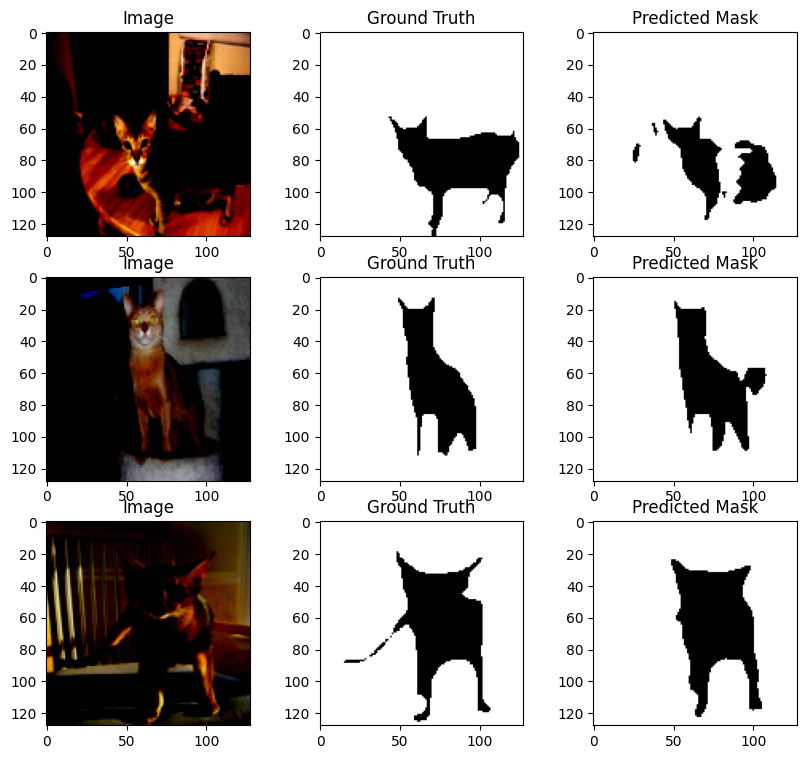

In [30]:
trainer.inference_and_plot_samples(n_samples=3)